# Task 2.2 Notebook 1: Merge four cervical cancer datasets

**Goal.** Build one matrix from GSE6791, GSE9750, GSE63514 and GSE67522 (Wang et al.).
The exam asks for a merged dataset, then DGE with |logFC| >= 1.5 and adjusted p < 0.05
in the next notebook.


## Key terms used in this notebook

| Term | Simple explanation |
| ---- | ------------------ |
| Platform | The microarray chip (GPL number). Different chips measure different probes. |
| Shared genes | Genes present on all four platforms after mapping. |
| Study-wise centering | Subtract each study's gene mean. A simple batch adjustment. |
| Batch effect | Systematic difference by study/platform, not by biology. |
| ComBat | A fuller batch-effect model. We did **not** run ComBat. |

Centering reduces systematic differences between studies, but it is simpler than ComBat.

Wang et al. ran DGE in each study and then compared lists. We merge samples first, so this
is **not** an exact replication.


**Batch handling.** Per-dataset gene centering reduces study-specific baseline shifts so PCA no longer separates platforms as strongly. This is **not** equivalent to a full batch-effect model such as **ComBat** (`sva`). Do not say “we ran ComBat” unless ComBat was actually fit.

**Wang vs this merge.** Wang et al. (2022) ran DGE **per study** and intersected DEG lists. This exam **merges samples first**, then runs DGE on the master matrix. Recovering 10/10 published hub genes is an **external benchmark / concordance**, not an exact replication of Wang’s workflow.


## 1. Setup and platform map

In [1]:
# Each dataset was measured on one platform, and each platform has its own probe to gene
# annotation. We load the three annotation maps and say which platform each dataset uses.
import warnings
warnings.filterwarnings("ignore")
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import task2_2_lib as lib2

DATA = pathlib.Path("../01_Data")
OUT = pathlib.Path("../04_Analysis")
FIG = OUT / "figures"

platform = {"GSE6791": "GPL570", "GSE9750": "GPL96", "GSE63514": "GPL570", "GSE67522": "GPL10558"}
maps = {}
for gpl in ["GPL570", "GPL96", "GPL10558"]:
    mp = pd.read_csv(DATA / f"{gpl}_probe_to_symbol.csv")
    mp["ID"] = mp["ID"].astype(str)
    maps[gpl] = mp
    print(f"{gpl}: {len(mp)} annotated probes, {mp['symbol'].nunique()} genes")

GPL570: 45118 annotated probes, 22189 genes
GPL96: 21156 annotated probes, 13299 genes
GPL10558: 31266 annotated probes, 20762 genes


The platforms have different numbers of probes. We can only merge genes that
exist on all of them. That is why the master matrix is smaller than any single chip.


## 2. Load each dataset as a clean cancer versus normal gene matrix

In [2]:
# For every dataset we read the FULL series matrix, label cancer vs normal,
# drop non-cervical samples, log2-transform if needed, and collapse probes to genes.
from IPython.display import display
from task2_1_lib import skim_summary

order = ["GSE6791", "GSE9750", "GSE63514", "GSE67522"]
frames, labels, audits = {}, {}, []
for gse in order:
    path = DATA / f"geo_raw/{gse}_series_matrix.txt.gz"
    if not path.exists():
        lib2.download_series_matrix(gse, path)
    expr_raw, meta = lib2.read_series_matrix(path)
    print(f"{gse}: raw {expr_raw.shape[0]} probes × {expr_raw.shape[1]} samples")
    skim_summary(
        expr_raw.T,
        title=f"{gse} raw expression (samples × probes, compact skim)",
        name=gse,
    )
    meta_tbl = pd.DataFrame([{
        "Dataset": gse,
        "Platform": platform[gse],
        "Raw samples": expr_raw.shape[1],
        "Raw probes": expr_raw.shape[0],
    }])
    display(meta_tbl)

    g, y, aud = lib2.load_gse_gene_matrix_with_audit(
        gse, path, maps[platform[gse]])
    frames[gse], labels[gse] = g, y
    aud["Platform"] = platform[gse]
    audits.append(aud)
    skim_summary(
        g, y=y, title=f"{gse} after mapping (samples × genes)", name=gse,
        class_names={1: "Cancer", 0: "Normal"},
    )
    print(f"{gse}: kept {aud['Retained samples']} samples × {aud['Genes after mapping']} genes  "
          f"(cancer {aud['Cancer']}, normal {aud['Normal']}, excluded {aud['Excluded samples']})")


GSE6791: raw 54675 probes × 84 samples
GSE6791 raw expression (samples × probes, compact skim)


,dataset,orientation,n_samples,n_features,missing_cells,missing_pct,inf_cells,min,q1,median,mean,q3,max,sd,zero_var_features,duplicate_feature_names,duplicate_sample_index
0,GSE6791,samples × features,84,54675,0,0.0,0,3.215146,5.84381,7.049815,7.161614,8.280861,14.920005,1.866286,0,0,0


Wide matrix (84 rows × 54675 cols): compact skimr-style summary (full per-column skimr not shown).


,Dataset,Platform,Raw samples,Raw probes
0,GSE6791,GPL570,84,54675


  GSE6791: excluding 56 samples (non-cervical / cell line)


...

Wide matrix (42 rows × 42670 cols): compact skimr-style summary (full per-column skimr not shown).


,Dataset,Platform,Raw samples,Raw probes
0,GSE67522,GPL10558,42,42670


GSE67522 after mapping (samples × genes)


,dataset,orientation,n_samples,n_features,missing_cells,missing_pct,inf_cells,min,q1,median,mean,q3,max,sd,zero_var_features,duplicate_feature_names,duplicate_sample_index,Cancer,Normal
0,GSE67522,samples × features,42,19430,0,0.0,0,4.5187,4.807209,5.566395,6.554281,7.97164,14.329867,2.136208,0,0,0,20,22


Wide matrix (42 rows × 19430 cols): compact skimr-style summary (full per-column skimr not shown).
GSE67522: kept 42 samples × 19430 genes  (cancer 20, normal 22, excluded 0)


## Dataset audit before merge

The exam asks us to merge four GEO series and notes that sample sizes can differ from Wang
et al. because platforms and GEO records can be updated. The table below is computed from
the files we actually downloaded. We do not change labels to copy Wang's historical counts.

Raw GEO tables are **probes × samples**. After mapping they are **samples × genes**.


In [3]:
audit_tbl = pd.DataFrame(audits)
cols = ["Dataset", "Platform", "Raw samples", "Raw probes", "Excluded samples",
        "Retained samples", "Cancer", "Normal", "Genes after mapping",
        "Missing cells (raw)", "Min (raw finite)", "Median (raw finite)", "Max (raw finite)"]
display(audit_tbl[cols])
audit_tbl.to_csv(OUT / "cervical_dataset_audit.csv", index=False)
print("Saved 04_Analysis/cervical_dataset_audit.csv")

from task2_1_lib import quick_expression_skim
print("\nskimr-style summary after probe-to-gene mapping (compact stats only):")
skim_rows = []
for gse in order:
    sk = quick_expression_skim(
        frames[gse], labels[gse], name=gse, class_names={1: "Cancer", 0: "Normal"})
    skim_rows.append(sk)
skim = pd.concat(skim_rows, ignore_index=True)
display(skim.round(4))


,Dataset,Platform,Raw samples,Raw probes,Excluded samples,Retained samples,Cancer,Normal,Genes after mapping,Missing cells (raw),Min (raw finite),Median (raw finite),Max (raw finite)
0,GSE6791,GPL570,84,54675,56,28,20,8,22836,0,3.215146,7.049815,14.920005
1,GSE9750,GPL96,66,22283,9,57,33,24,13909,0,0.000000,81.500000,76931.700000
2,GSE63514,GPL570,128,54675,76,52,28,24,22836,0,-0.892617,3.317056,16.976383
3,GSE67522,GPL10558,42,42670,0,42,20,22,19430,0,21.922624,29.509210,20592.003950


Saved 04_Analysis/cervical_dataset_audit.csv

skimr-style summary after probe-to-gene mapping (compact stats only):


,dataset,orientation,n_samples,n_features,missing_cells,missing_pct,inf_cells,min,q1,median,mean,q3,max,sd,zero_var_features,duplicate_feature_names,duplicate_sample_index,Cancer,Normal
0,GSE6791,samples × features,28,22836,0,0.0,0,3.3071,6.6844,7.8890,8.0084,9.2999,14.9200,1.9398,0,0,0,20,8
1,GSE9750,samples × features,57,13909,0,0.0,0,0.0000,5.2555,6.9495,6.8605,8.4529,16.0789,2.4684,0,0,0,33,24
2,GSE63514,samples × features,52,22836,0,0.0,0,0.1493,2.7426,5.4511,6.2362,9.4754,16.9764,3.7199,0,0,0,28,24
3,GSE67522,samples × features,42,19430,0,0.0,0,4.5187,4.8072,5.5664,6.5543,7.9716,14.3299,2.1362,0,0,0,20,22


Each study starts with a different number of probes and samples. Many samples
are excluded because they are not cervical cancer vs normal (for example cell lines). The
gene counts also differ by platform. That is why we later keep only shared genes.

We cannot conclude biology from the sample counts alone. The skim is only a data-quality check.


## Sample counts versus Wang et al.


In [4]:
# Wang et al. (2022) reported a combined 101 cancer and 67 normal samples.
# Per-dataset Wang counts are not copied here if they are not in our files.
wang_note = pd.DataFrame([
    {"Source": "Wang et al. 2022 (paper total)", "Cancer": 101, "Normal": 67, "Total": 168,
     "Note": "Historical published counts"},
    {"Source": "This pipeline (GEO files today)",
     "Cancer": int(sum((labels[g] == 1).sum() for g in order)),
     "Normal": int(sum((labels[g] == 0).sum() for g in order)),
     "Total": int(sum(len(labels[g]) for g in order)),
     "Note": "Current GEO parse; exam says sizes may differ after platform updates"},
])
display(wang_note)
print("GSE67522 contributes extra normal samples in our parse. We keep GEO labels.")


,Source,Cancer,Normal,Total,Note
0,Wang et al. 2022 (paper total),101,67,168,Historical published counts
1,This pipeline (GEO files today),101,78,179,Current GEO parse; exam says sizes may differ ...


GSE67522 contributes extra normal samples in our parse. We keep GEO labels.


The current GEO files contain a different number of eligible samples than those reported
by Wang et al. The exam also notes that sample sizes may differ because omics platforms
and GEO records can be updated.


Sample counts are close to Wang et al. on the cancer side. The normal count is
higher here, mainly because GSE67522 keeps more normal samples in the current GEO file.
We do not force Wang's 67 normals.


## 3. Merge on the shared genes

In [5]:
# We keep the genes present in all four datasets, center each gene within each dataset to
# remove the platform baseline, then stack the samples into one master matrix. Centering
# keeps the cancer versus normal difference inside each dataset, so the merged fold change
# stays on the log2 scale that the DEG cutoff needs.
from IPython.display import display

master, y_all, batch, common = lib2.merge_datasets(
    [frames[g] for g in order], [labels[g] for g in order], order)
print(f"Shared genes across all four platforms: {len(common):,}")
print(f"Master matrix: {master.shape[0]} samples × {master.shape[1]:,} genes")
print(f"Cancer: {int((y_all == 1).sum())}   Normal: {int((y_all == 0).sum())}")
out = master.copy()
out.insert(0, "target", y_all)
out.insert(1, "batch", batch)

meta = out[["target", "batch"]].copy()
meta["class"] = meta["target"].map({1: "Cancer", 0: "Normal"})
print("\nMaster sample metadata (no expression columns printed):")
display(meta.groupby("batch").size().reset_index(name="samples"))
display(meta.groupby(["batch", "class"]).size().reset_index(name="samples"))

out.to_csv(DATA / "cervical_master.csv", index=False)
print(f"Saved expression matrix + metadata: {DATA / 'cervical_master.csv'}")
print(f"  ({out.shape[0]} samples × {out.shape[1] - 2:,} genes + target + batch)")


Shared genes across all four platforms: 12,191
Master matrix: 179 samples × 12,191 genes
Cancer: 101   Normal: 78

Master sample metadata (no expression columns printed):


,batch,samples
0,GSE63514,52
1,GSE67522,42
2,GSE6791,28
3,GSE9750,57


,batch,class,samples
0,GSE63514,Cancer,28
1,GSE63514,Normal,24
2,GSE67522,Cancer,20
3,GSE67522,Normal,22
4,GSE6791,Cancer,20
5,GSE6791,Normal,8
6,GSE9750,Cancer,33
7,GSE9750,Normal,24


Saved expression matrix + metadata: ..\01_Data\cervical_master.csv
  (179 samples × 12,191 genes + target + batch)


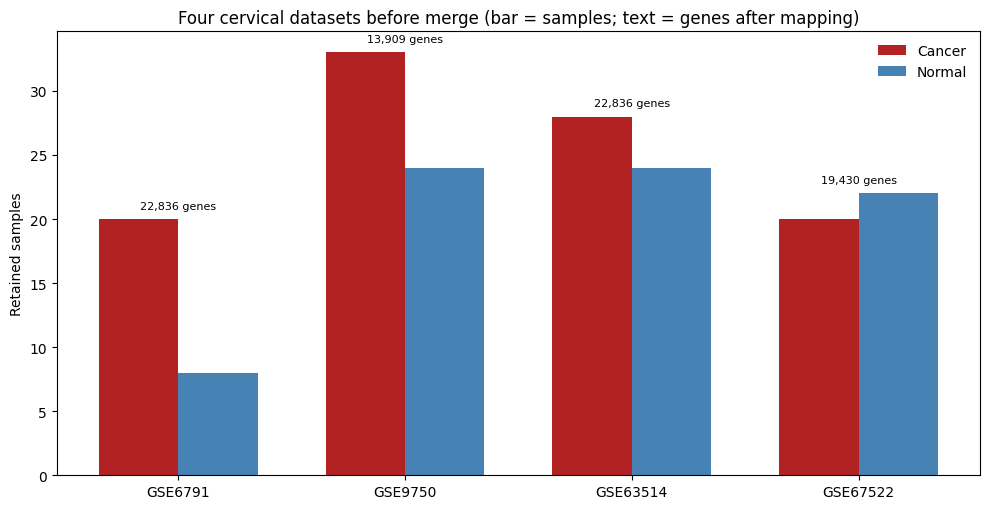

Flow:
GEO probes × samples  ->  filter samples  ->  map probes to genes
->  shared genes  ->  study-wise centering  ->  master 179 × 12,191


In [6]:
# Compact dimension figure (counts come from the audit + merge, not from typed numbers).
fig, ax = plt.subplots(figsize=(10, 5.2))
xs = np.arange(len(order))
w = 0.35
c_counts = [int((labels[g] == 1).sum()) for g in order]
n_counts = [int((labels[g] == 0).sum()) for g in order]
ax.bar(xs - w / 2, c_counts, w, label="Cancer", color="firebrick")
ax.bar(xs + w / 2, n_counts, w, label="Normal", color="steelblue")
for i, gse in enumerate(order):
    n_g = frames[gse].shape[1]
    ax.text(i, max(c_counts[i], n_counts[i]) + 0.8, f"{n_g:,} genes", ha="center", fontsize=8)
ax.set_xticks(xs)
ax.set_xticklabels(order)
ax.set_ylabel("Retained samples")
ax.set_title("Four cervical datasets before merge (bar = samples; text = genes after mapping)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG / "task2_2_dataset_dimensions.png", dpi=150)
plt.show()
print("Flow:")
print("GEO probes × samples  ->  filter samples  ->  map probes to genes")
print("->  shared genes  ->  study-wise centering  ->  "
      f"master {master.shape[0]} × {master.shape[1]:,}")


After the merge we have 179 samples (101 cancer, 78 normal) and the genes
shared by all platforms. The exact gene count is printed by the code / `report_data.json`.
Do not mix this number with older handwritten figures.


## 4. Check that the batch centering worked

## Note on Wang et al. vs this merge

Wang et al. (2022) ran differential expression on each of the four GEO series separately and
then took the intersection of DEGs across studies before PPI and hub-gene analysis.

The final exam instead asks us to harmonize and merge the four datasets into one master set and
run the pipelines on that unified cohort. This is not an exact reproduction of Wang's workflow;
we use Wang's ten reported hub genes as an external literature benchmark, not as a target to match.


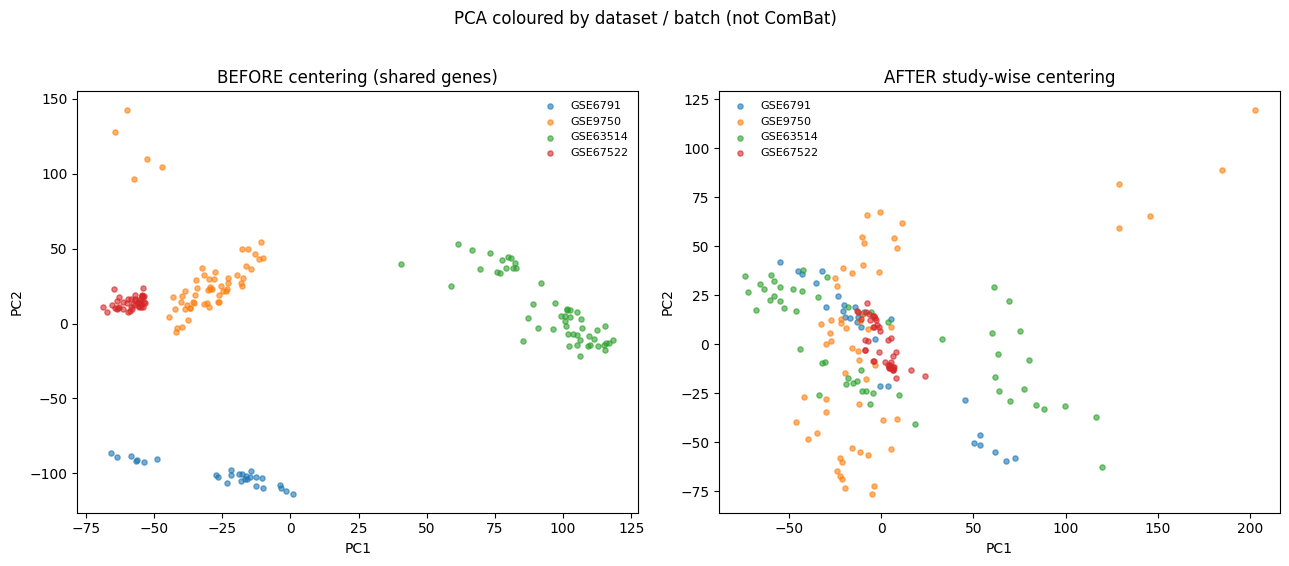

In [7]:
# True before vs after: the same shared genes, without and with study-wise centering.
# The saved master file stays the centered matrix from the previous cell.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

before, _, batch_b, _ = lib2.merge_datasets(
    [frames[g] for g in order], [labels[g] for g in order], order, center=False)

def _pca2(mat):
    return PCA(n_components=2, random_state=42).fit_transform(StandardScaler().fit_transform(mat.values))

pcs_before = _pca2(before)
pcs_after = _pca2(master)
colors = {"GSE6791": "tab:blue", "GSE9750": "tab:orange", "GSE63514": "tab:green", "GSE67522": "tab:red"}
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
for pcs, a, title in [(pcs_before, ax[0], "BEFORE centering (shared genes)"),
                      (pcs_after, ax[1], "AFTER study-wise centering")]:
    for b in order:
        m = batch == b
        a.scatter(pcs[m, 0], pcs[m, 1], s=14, alpha=0.6, label=b, color=colors[b])
    a.set_title(title)
    a.set_xlabel("PC1")
    a.set_ylabel("PC2")
    a.legend(fontsize=8, frameon=False)
fig.suptitle("PCA coloured by dataset / batch (not ComBat)", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "task2_2_merge_pca.png", dpi=150)
plt.show()


If studies sit in separate clouds before centering and overlap more after
centering, part of the platform shift was reduced. PCA is exploratory. It does not prove
that all batch effects were removed. We did not run ComBat.


## Limitations

- Different platforms measure different probes, so we keep only shared genes.
- Study-wise centering is simpler than ComBat.
- Current GEO sample counts differ from Wang's published 101 / 67 split.
- Merge-first DGE is not Wang's original per-study workflow.

## Notebook 1 summary

Four GEO series were audited (raw and cleaned dimensions), mapped to genes, merged on
shared genes, and centered by study.

Oral-defense questions are consolidated in `2_0_final_overview.ipynb` (section **Oral defense**).
